### DTW test for KARAT

In [18]:
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import obspy


from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    find_paths,
    find_date_in_strings,
)
from seismicif.metrics import iou
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from dynamicTreeCut import cutreeHybrid
from scipy.spatial.distance import pdist
from datetime import timedelta
from seismicif.datamod.preproc_utils import preproc_stream
from seismicif.datamod.loading_utils import limit_segment_length
import joblib
from tqdm import tqdm

from seismicif.dtw import (
    segment_dtw,
    distribute_pairwise_segment_dtw,
    distribute_reference_segment_dtw,
)
import multiprocessing as mp

In [9]:
station = "KARAT"
control_station = "KARAT_CONT"
network = "DK"
paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)
control_paths = find_paths("DK", "KARAT_CONT", "HHZ.D", start=2022, stop=2023)

segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)
control_segments = pd.read_csv(
    f"../output/{network}/if/segments/{control_station}.csv", index_col=0
)

if_model = joblib.load(f"../output/{network}/if/models/{station}.joblib")
control_if_model = joblib.load(
    f"../output/{network}/if/models/{control_station}.joblib"
)

num_segments = 50

In [22]:
control_ref_segments = []
for i in tqdm(range(200)):
    control_ref_segments.append(
        limit_segment_length(
            control_segments["start"][i],
            control_segments["stop"][i],
            control_paths,
            control_if_model,
        )
    )

100%|██████████| 200/200 [02:05<00:00,  1.59it/s]


In [23]:
n = len(control_ref_segments)
indices = [(i, j, control_ref_segments) for i in range(n) for j in range(i + 1, n)]

In [24]:
with mp.Pool(mp.cpu_count()) as pool:
    results = list(
        tqdm(
            pool.imap(distribute_pairwise_segment_dtw, indices),
            total=len(indices),
            desc=f"{station}: Performing Pairwise Segment DTW",
        )
    )

KARAT: Performing Pairwise Segment DTW: 100%|██████████| 19900/19900 [4:15:52<00:00,  1.30it/s]   


In [28]:
indices = [(i, j) for i in range(n) for j in range(i + 1, n)]

In [29]:
with open("../output/backup/karat_cont_200.pkl", "wb") as f:
    pickle.dump([indices, results], f)

In [32]:
with open("../output/backup/karat_cont_200.pkl", "rb") as f:
    indices, results = pickle.load(f)

In [33]:
nseg = max(indices)[1] + 1
D = np.zeros([nseg, nseg])

for k in range(len(indices)):
    i, j = indices[k]
    D[i, j] = np.median(results[k][0])
    D[j, i] = D[i, j]

D = squareform(D)

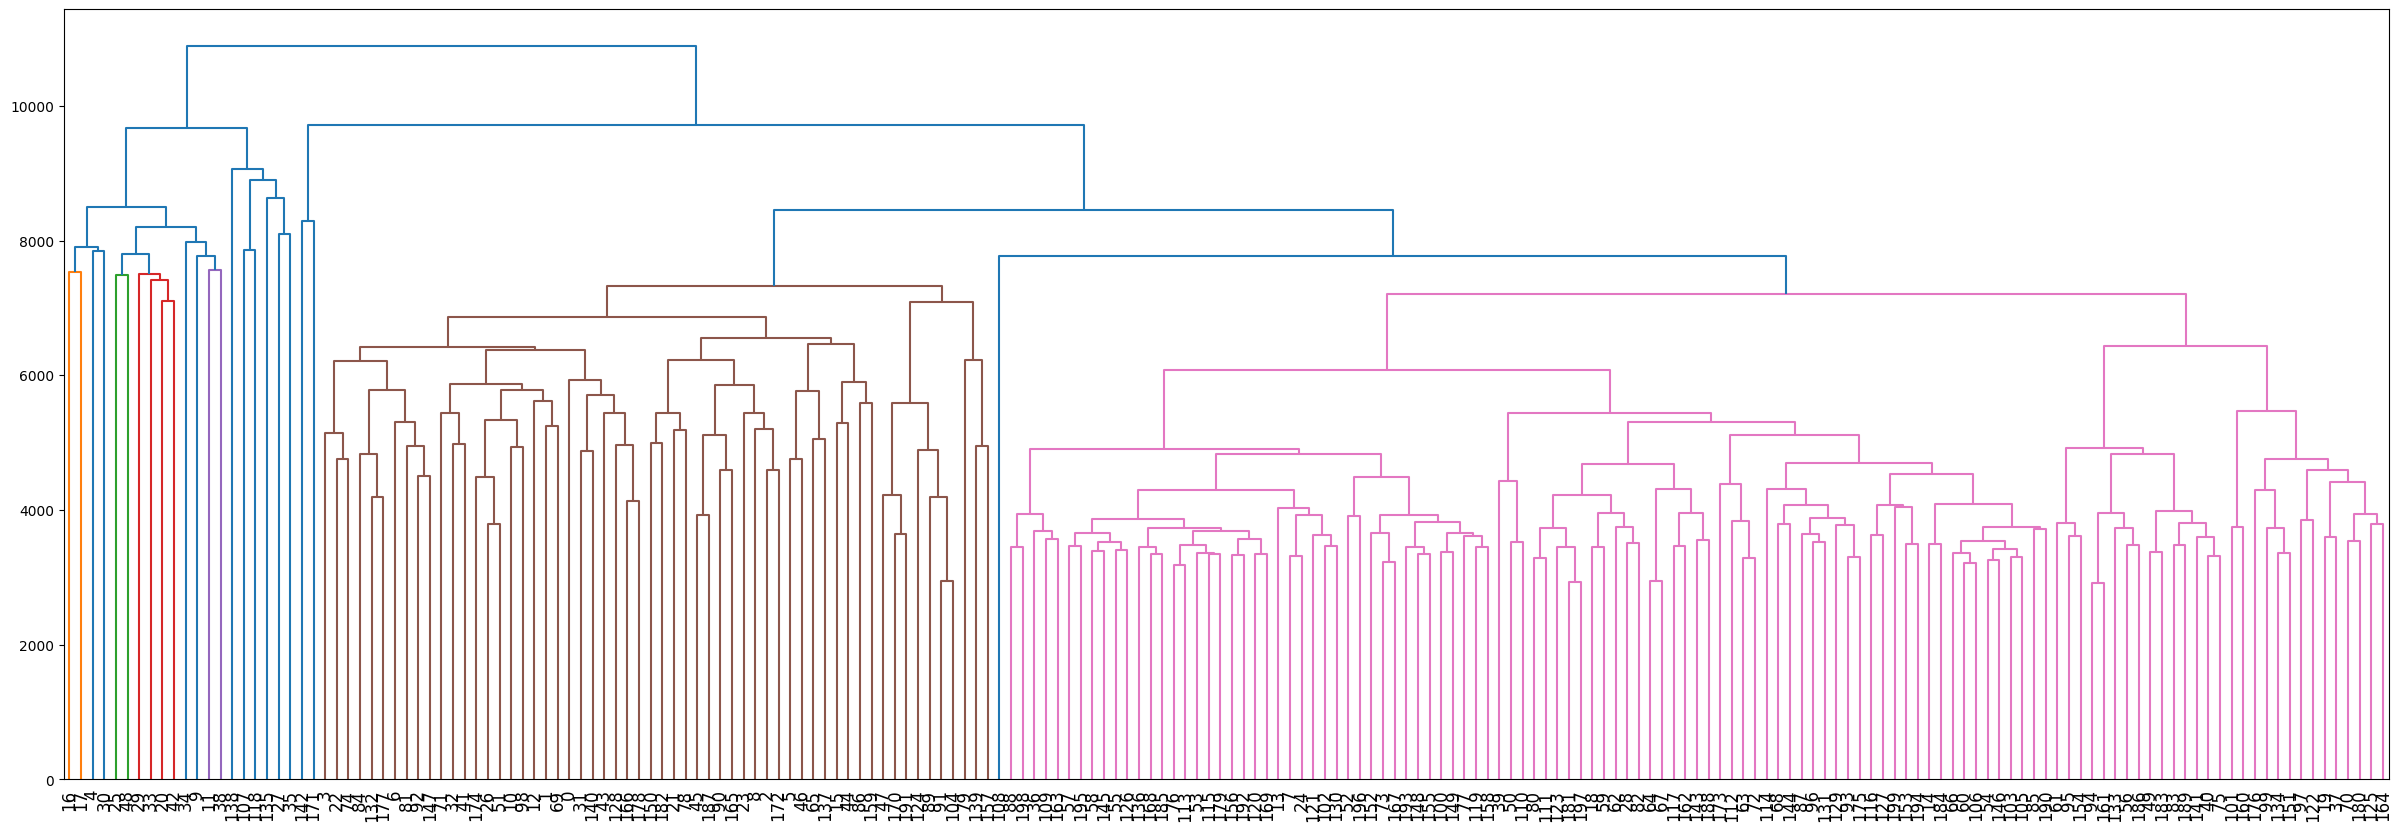

In [47]:
Z = linkage(D, method="complete")
plt.figure(figsize=(30, 10))
dendrogram(Z, leaf_font_size=12)
plt.show()

In [63]:
clusters = cutreeHybrid(Z, D, minClusterSize=1, deepSplit=3)
clusters = clusters["labels"]

..cutHeight not given, setting it to 10812.925440965177  ===>  99% of the (truncated) height range in dendro.
..done.


In [73]:
top_segments = control_segments.copy().iloc[:200, :]

ref_templates = []
for cl in np.unique(clusters):
    ref_templates.append(top_segments[clusters == cl].index[0])

ref_templ_idx = np.sort(np.array(ref_templates))

control_ref_segments = [control_ref_segments[i] for i in ref_templ_idx]

In [84]:
paired_segments = []
for i in tqdm(range(len(if_segments))):
    paired_segments.append((if_segments[i], control_ref_segments))

100%|██████████| 605/605 [00:00<00:00, 605188.15it/s]


In [ ]:
with mp.Pool(mp.cpu_count()) as pool:
    results = list(
        tqdm(
            pool.imap(distribute_reference_segment_dtw, paired_segments),
            total=len(paired_segments),
            desc=f"{station}: Performing Reference Segment DTW",
        )
    )

KARAT: Performing Reference Segment DTW:   0%|          | 3/605 [08:02<21:28:06, 128.38s/it]

In [ ]:
with open(f"../output/backup/{station}_control_200.pkl", "wb") as f:
    pickle.dump(results, f)

In [83]:
len(if_segments)

605

In [12]:
if_segments = []
for i in tqdm(range(segments.shape[0])):
    if_segments.append(
        limit_segment_length(segments["start"][i], segments["stop"][i], paths, if_model)
    )

 15%|█▍        | 90/605 [03:35<25:27,  2.97s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
 16%|█▌        | 98/605 [04:01<32:07,  3.80s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
 16%|█▋        | 99/605 [04:04<29:18,  3.48s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
 20%|██        | 121/605 [05:05<33:33,  4.16s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)

In [15]:
paired_segments = []
for i in range(len(if_segments)):
    paired_segments.append((if_segments[i], control_ref_segments))

In [19]:
with mp.Pool(mp.cpu_count()) as pool:
    results = list(
        tqdm(
            pool.imap(distribute_reference_segment_dtw, paired_segments),
            total=len(paired_segments),
            desc=f"{station}: Performing Reference Segment DTW",
        )
    )

KARAT: Performing Reference Segment DTW: 100%|██████████| 605/605 [6:55:09<00:00, 41.17s/it]  


In [20]:
with open("../output/backup/karat_control.pkl", "wb") as f:
    pickle.dump(results, f)

In [ ]:
catalog = pd.read_csv("../catalogs/DK/KARAT.csv")
catalog = preproc_flow_annotations(catalog)


model_path = f"../output/{network}/if/models/"
if_mod = joblib.load(f"{model_path}/{station}.joblib")

In [3]:
ref_segments = []
for i in tqdm(range(200)):
    ref_segments.append(
        limit_segment_length(segments["start"][i], segments["stop"][i], paths, if_mod)
    )

 45%|████▌     | 90/200 [03:39<05:23,  2.94s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
 49%|████▉     | 98/200 [04:04<06:20,  3.73s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
 50%|████▉     | 99/200 [04:07<05:47,  3.44s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
 60%|██████    | 121/200 [05:11<05:41,  4.32s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)

In [4]:
n = len(ref_segments)
indices = [(i, j, ref_segments) for i in range(n) for j in range(i + 1, n)]

In [5]:
with mp.Pool(mp.cpu_count()) as pool:
    results = list(
        tqdm(
            pool.imap(distribute_pairwise_segment_dtw, indices),
            total=len(indices),
            desc=f"{station}: Performing Pairwise Segment DTW",
        )
    )

KARAT: Performing Pairwise Segment DTW: 100%|██████████| 19900/19900 [5:00:37<00:00,  1.10it/s]   


In [6]:
indices = [(i, j) for i in range(n) for j in range(i + 1, n)]

with open("../output/backup/karat200.pkl", "wb") as f:
    pickle.dump([indices, results], f)

In [7]:
with open("../output/backup/karat200.pkl", "rb") as f:
    results = pickle.load(f)

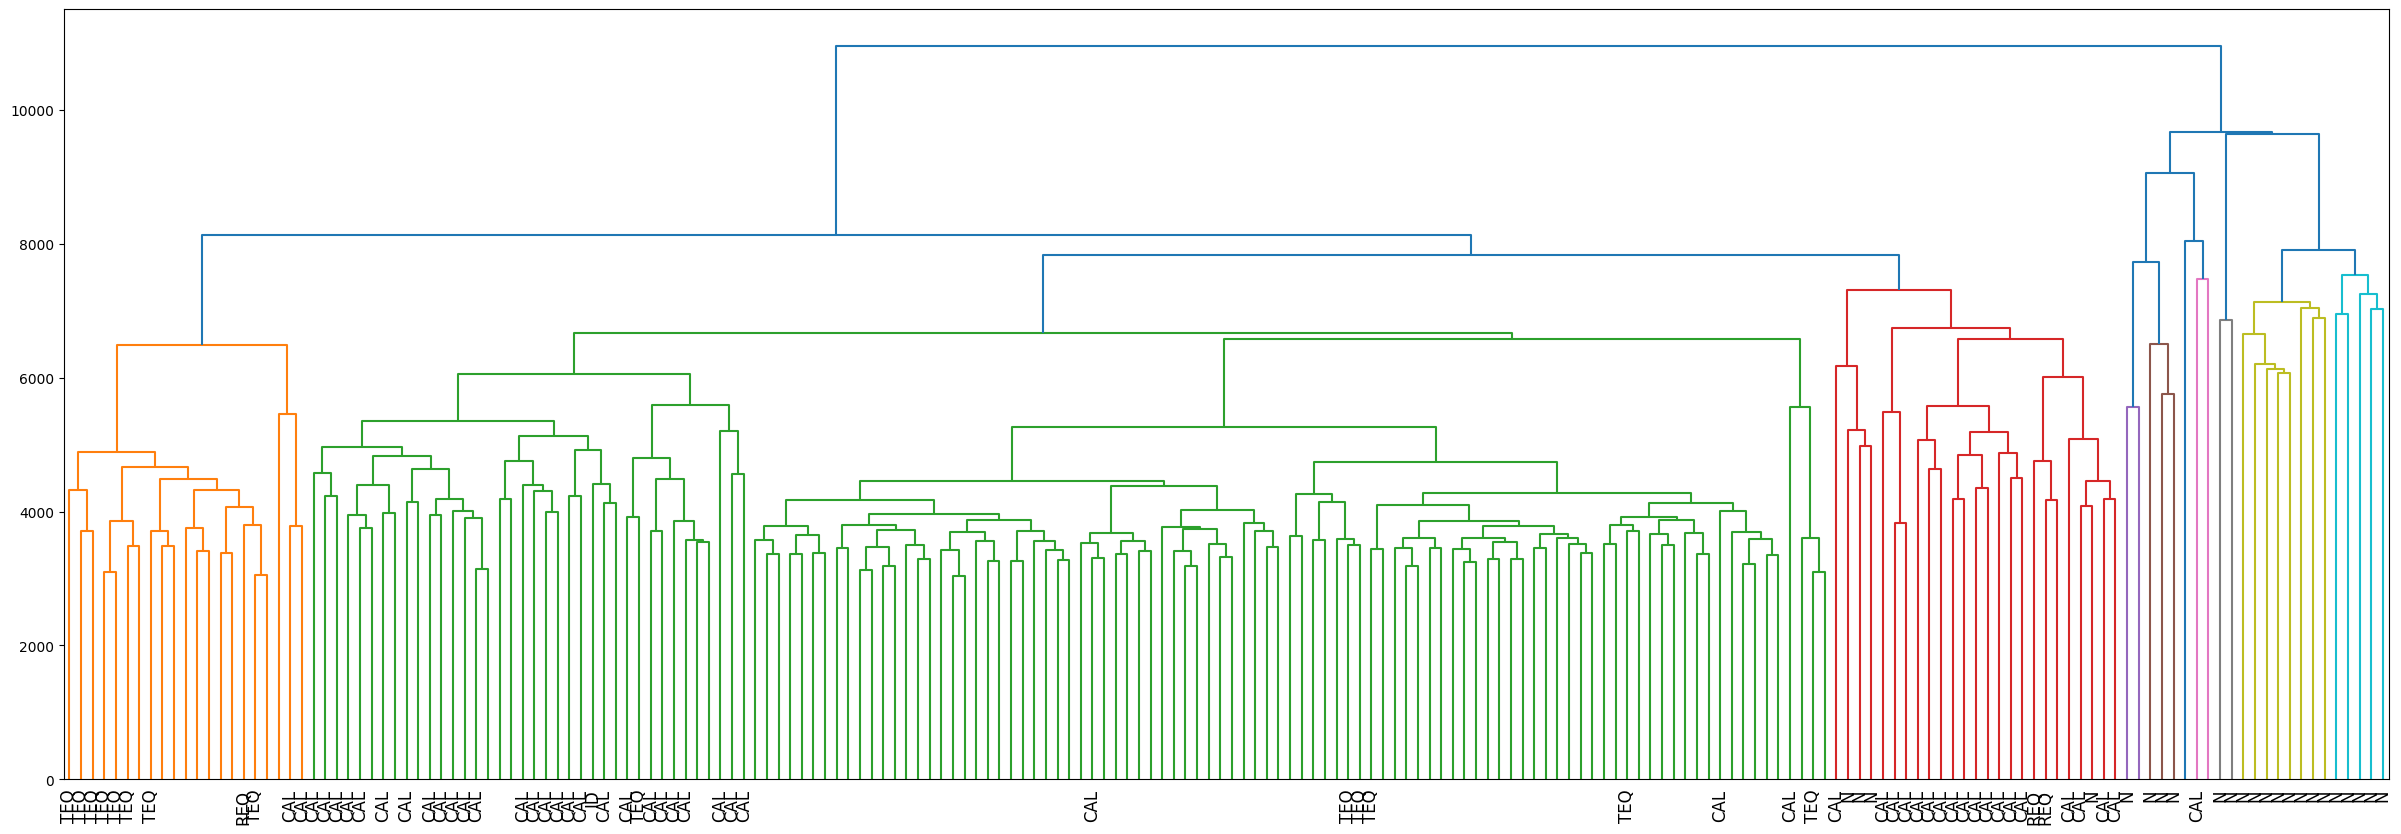

In [12]:
Z = linkage(D, method="complete")
plt.figure(figsize=(30, 10))
dendrogram(Z, labels=labs[:200], leaf_font_size=12)
plt.show()

In [13]:
clusters = cutreeHybrid(Z, D, minClusterSize=1, deepSplit=3)

..cutHeight not given, setting it to 10880.557230864666  ===>  99% of the (truncated) height range in dendro.
..done.


In [14]:
clusters["labels"].max()

43

In [15]:
labs = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[0]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)

In [16]:
clusters = clusters["labels"]

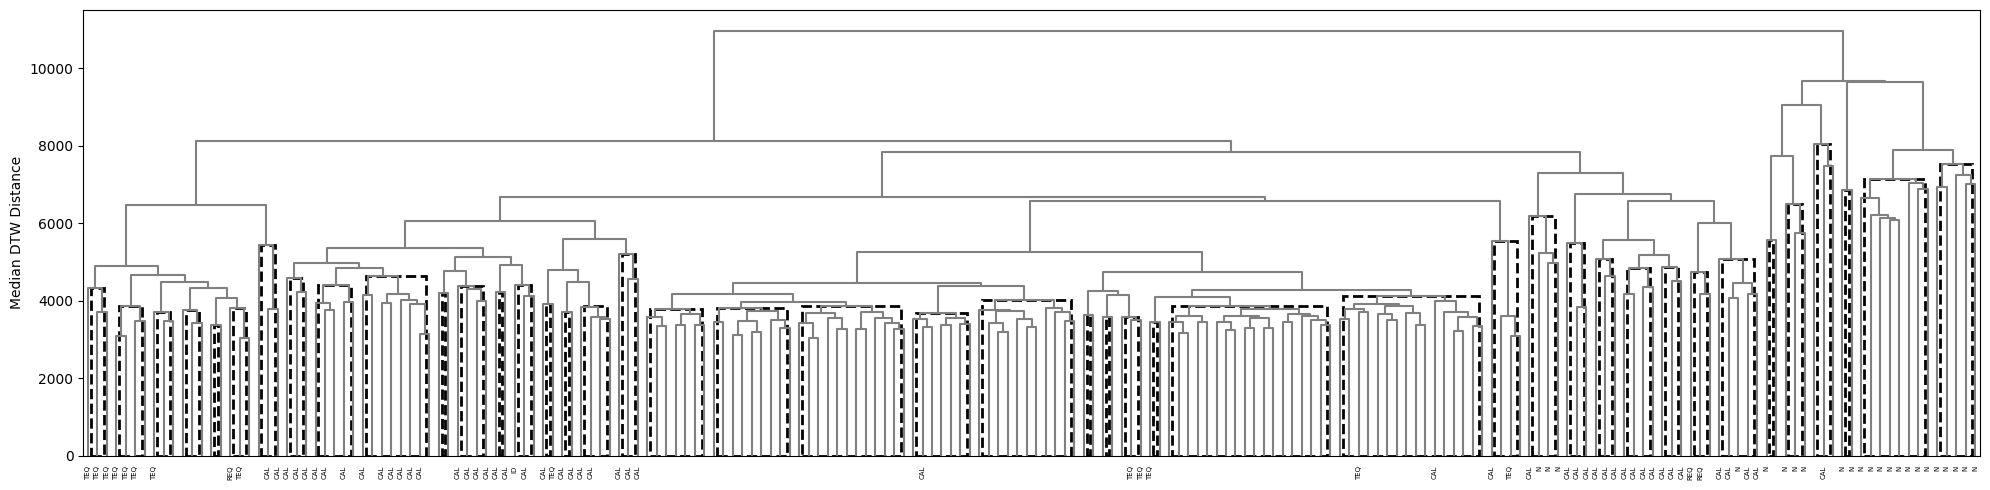

In [18]:
plt.figure(figsize=(20, 5))
# --- dendrogram ---
ddata = dendrogram(Z, labels=labs[:200], link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 8  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()

In [19]:
top_segments = segments.copy().iloc[:200, :]

ref_templates = []
for cl in np.unique(clusters):
    ref_templates.append(top_segments[clusters == cl].index[0])

ref_templ_idx = np.sort(np.array(ref_templates))

In [20]:
segments.iloc[ref_templ_idx]

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2022-05-30T13:35:29.900000Z,2022-05-30T13:39:39.900000Z,2022-05-30T13:35:29.900000Z,0.747250,0.365634,16,N
1,2022-06-03T10:01:34.625000Z,2022-06-03T10:05:44.625000Z,2022-06-03T10:04:04.625000Z,0.742787,0.366732,10,N
3,2022-06-14T00:00:00.000000Z,2022-06-14T14:47:30.000000Z,2022-06-14T10:18:20.000000Z,0.742142,0.540869,16,N
11,2022-10-10T03:09:05.350000Z,2022-10-10T03:29:55.350000Z,2022-10-10T03:10:45.350000Z,0.726770,0.473050,15,CAL
12,2023-08-03T00:21:40.000000Z,2023-08-03T00:33:20.000000Z,2023-08-03T00:25:50.000000Z,0.723054,0.468209,15,ID
16,2023-07-27T06:56:40.000000Z,2023-07-27T07:06:40.000000Z,2023-07-27T07:00:00.000000Z,0.720379,0.711134,7,CAL
17,2023-07-03T09:22:22.320000Z,2023-07-03T09:39:52.320000Z,2023-07-03T09:34:52.320000Z,0.719906,0.463514,15,CAL
20,2022-09-19T18:14:59.410000Z,2022-09-19T18:18:19.410000Z,2022-09-19T18:15:49.410000Z,0.709257,0.682285,12,TEQ
21,2023-07-18T17:24:52.320000Z,2023-07-18T17:31:32.320000Z,2023-07-18T17:28:12.320000Z,0.707347,0.367114,13,N
22,2023-04-11T11:35:42.320000Z,2023-04-11T11:42:22.320000Z,2023-04-11T11:37:22.320000Z,0.704491,0.443061,15,CAL


 15%|█▍        | 90/605 [03:39<25:34,  2.98s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
 16%|█▌        | 98/605 [04:05<32:09,  3.81s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
 16%|█▋        | 99/605 [04:08<29:56,  3.55s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
 20%|██        | 121/605 [05:12<37:32,  4.65s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)

In [ ]:
control_station = "KARAT_CONT"
network = "DK"
control_paths = find_paths("DK", "KARAT_CONT", "HHZ.D", start=2022, stop=2023)
control_model_path = f"../output/{network}/if/models/"
control_if_mod = joblib.load(f"{control_model_path}/{control_station}.joblib")

control_segments = []

for i in tqdm(range(len((if_segments)))):
    try:
        t0 = if_segments[i][2]
        t1 = if_segments[i][3]
        control_segments.append(
            limit_segment_length(t0, t1, control_paths, control_if_mod)
        )

    except:
        control_segments.append([])
        continue


control_if_scores = []
for i in range(len(control_segments)):
    if len(control_segments[i]) == 0:
        control_if_scores.append(np.nan)
        continue

    else:
        control_if_scores.append(np.max(control_segments[i][1]))
control_if_scores = np.array(control_if_scores)

100%|██████████| 605/605 [04:47<00:00,  2.10it/s]


In [62]:
np.sum(np.isnan(control_if_scores))

0

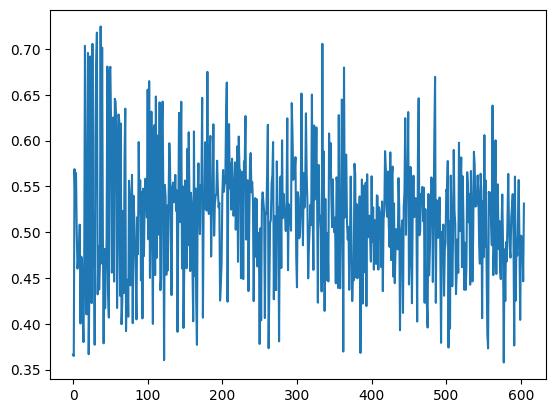

In [63]:
plt.plot(control_if_scores)

In [64]:
seg_dtw_distances = []
for i in tqdm(range(len(if_segments))):
    try:
        seg_dtw_distances.append(segment_dtw(if_segments[i], control_segments[i])[0])
    except Exception as e:
        seg_dtw_distances.append(np.nan)
        print(f"Error processing segment {i}: {e}")

100%|██████████| 605/605 [1:09:03<00:00,  6.85s/it]


In [65]:
meds = []
for i in range(len(seg_dtw_distances)):
    if np.any(np.isnan(seg_dtw_distances[i])):
        meds.append(np.nan)
        continue

    else:
        meds.append(np.nanmedian(seg_dtw_distances[i]))
meds = np.array(meds)

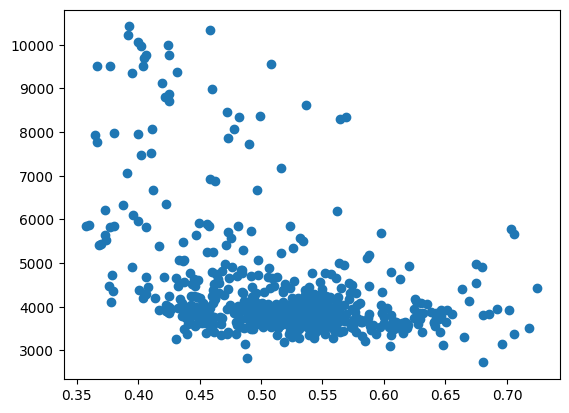

In [68]:
plt.scatter(control_if_scores, meds)

In [ ]:
X = np.hstack([control_if_scores.reshape(-1, 1), meds.reshape(-1, 1)])
np.save("../output/backup/karat_dtw_distances.npy", X)

100%|██████████| 605/605 [00:00<00:00, 604755.46it/s]


In [24]:
from seismicif.dtw import distribute_reference_segment_dtw

KARAT: Performing Reference Segment DTW: 100%|██████████| 605/605 [5:08:18<00:00, 30.58s/it]  


In [27]:
X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

In [54]:
Xa = X.copy()
Xa = np.delete(Xa, ref_templ_idx, axis=0)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens)
lens = lens.reshape(-1, 1)

Xa = np.hstack([Xa, lens])
Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.hstack([Xa, np.isnan(Xa[:, -1]).astype(float).reshape(-1, 1)])
Xa = np.nan_to_num(Xa, nan=0.5)

a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

In [55]:
ll = np.delete(labs, ref_templ_idx)

In [56]:
Z = linkage(Xa, method="ward")

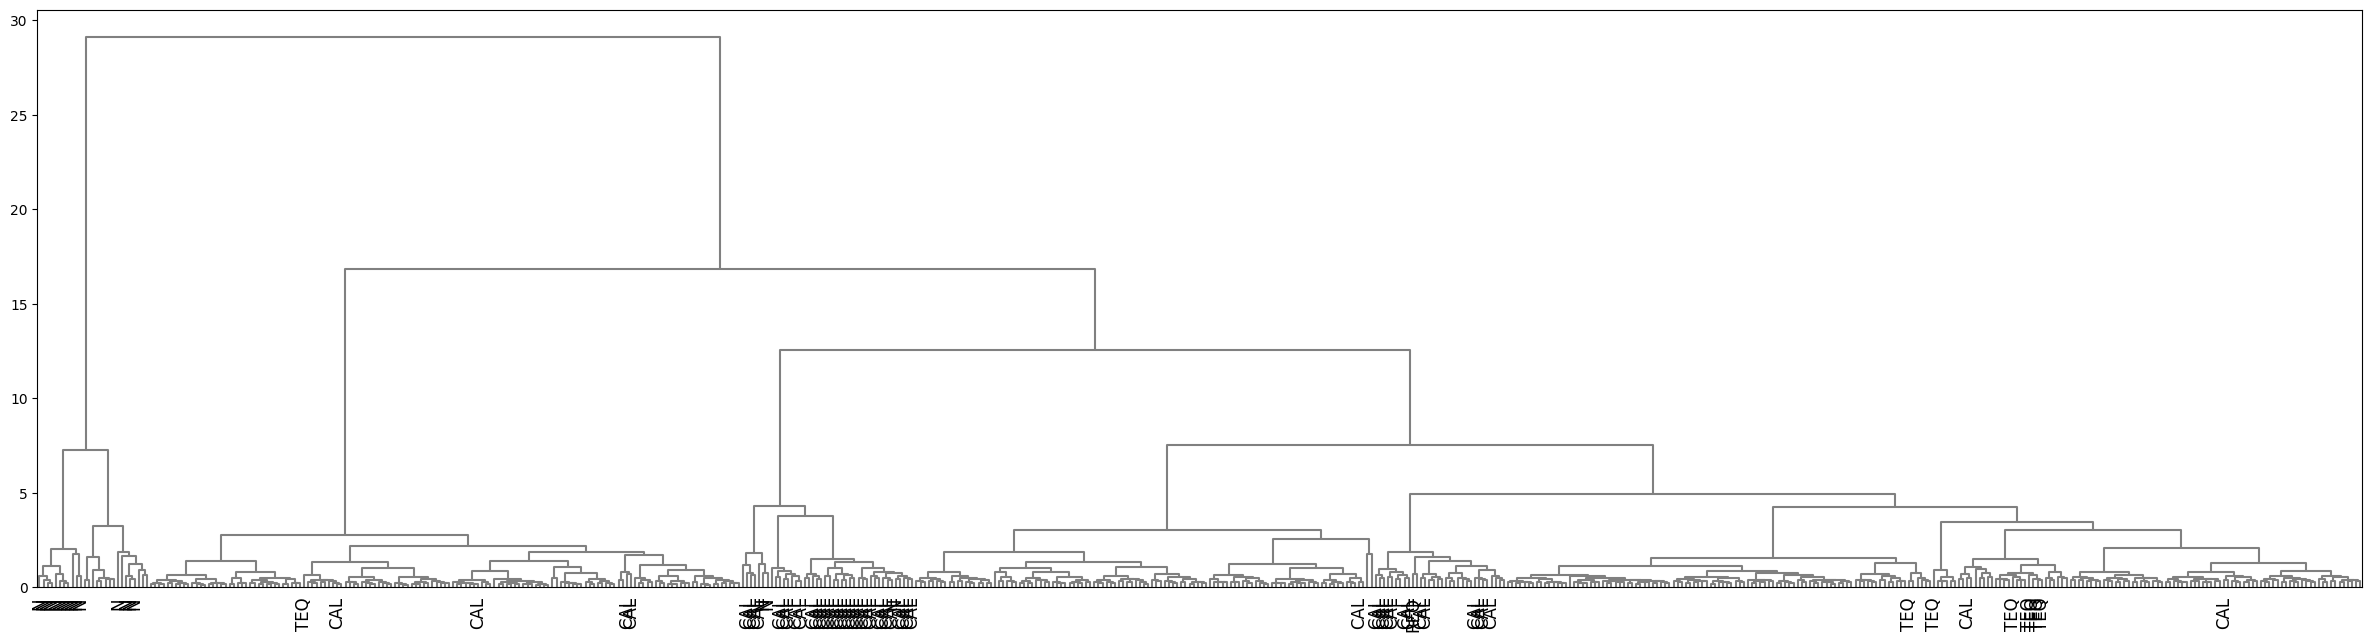

In [57]:
plt.figure(figsize=(30, 7.5))
ddata = dendrogram(Z, labels=ll, link_color_func=lambda k: "grey", leaf_font_size=12)

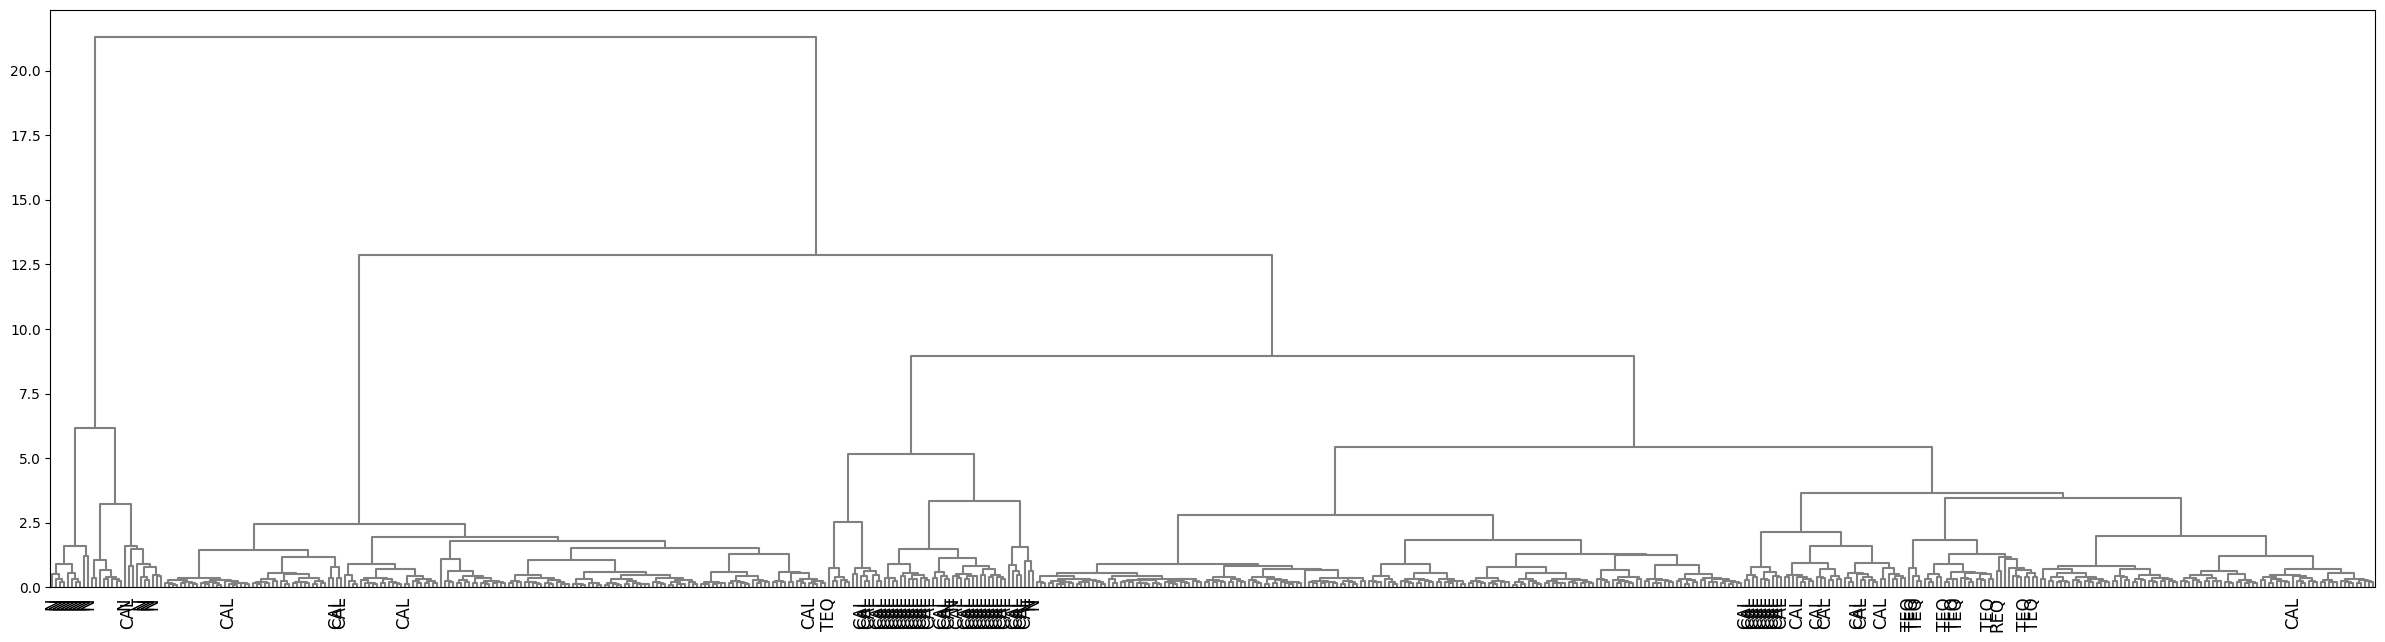

In [169]:
plt.figure(figsize=(30, 7.5))
ddata = dendrogram(Z, labels=ll, link_color_func=lambda k: "grey", leaf_font_size=12)

In [58]:
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]

..cutHeight not given, setting it to 28.817795800347813  ===>  99% of the (truncated) height range in dendro.
..done.


In [59]:
# segments = segments.drop(index=ref_templ_idx).reset_index(drop=True)

In [60]:
segments["cluster"] = clusters
segments["label"] = ll

In [61]:
def cluster_info(cluster):
    size = len(cluster)

    mapping = {"CAL": "MM", "ID": "MM", "TEQ": "EQ", "REQ": "EQ"}

    cluster["label"] = cluster["label"].replace(mapping)

    return cluster["label"].value_counts(dropna=False) / size

In [62]:
info = {}
for cl in np.unique(clusters):
    cluster = segments[clusters == cl].copy().reset_index(drop=True)
    info[cl] = cluster_info(cluster)


df = pd.DataFrame(info).T
df.fillna(0, inplace=True)
df

label,EQ,MM,N,None
1,0.009434,0.037736,0.000000,0.952830
2,0.009709,0.000000,0.000000,0.990291
3,0.012987,0.012987,0.000000,0.974026
4,0.000000,0.000000,0.000000,1.000000
5,0.000000,0.761905,0.071429,0.166667
6,0.000000,0.025000,0.000000,0.975000
7,0.000000,0.000000,0.000000,1.000000
8,0.031250,0.406250,0.000000,0.562500
9,0.185185,0.037037,0.000000,0.777778
10,0.000000,0.000000,0.250000,0.750000


In [65]:
cl = 9
segments[segments["cluster"] == cl]

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
29,2022-09-19T18:18:23.350000Z,2022-09-19T18:22:33.350000Z,2022-09-19T18:18:23.350000Z,0.671408,0.621032,9,TEQ
31,2023-07-14T09:39:02.320000Z,2023-07-14T09:43:12.320000Z,2023-07-14T09:39:02.320000Z,0.664421,0.600324,9,TEQ
34,2023-06-15T18:24:52.320000Z,2023-06-15T18:29:52.320000Z,2023-06-15T18:26:32.320000Z,0.660072,0.622133,9,TEQ
39,2023-04-02T18:22:30.000000Z,2023-04-02T18:26:40.000000Z,2023-04-02T18:23:20.000000Z,0.657752,0.636377,9,TEQ
66,2023-03-16T01:15:00.000000Z,2023-03-16T01:19:10.000000Z,2023-03-16T01:15:00.000000Z,0.645394,0.615351,9,None
74,2023-09-08T09:31:40.000000Z,2023-09-08T09:35:00.000000Z,2023-09-08T09:31:40.000000Z,0.641278,0.634034,9,TEQ
78,2023-04-03T03:15:50.000000Z,2023-04-03T03:20:00.000000Z,2023-04-03T03:16:40.000000Z,0.640198,0.631951,9,None
87,2023-02-25T13:37:54.910000Z,2023-02-25T13:41:14.910000Z,2023-02-25T13:37:54.910000Z,0.638859,0.624188,9,None
102,2022-09-29T15:36:44.335000Z,2022-09-29T15:39:14.335000Z,2022-09-29T15:36:44.335000Z,0.634990,0.581743,9,None
110,2022-12-20T10:42:30.000000Z,2022-12-20T10:46:40.000000Z,2022-12-20T10:42:30.000000Z,0.632196,0.594900,9,None


In [ ]:
clusters = clusters["labels"]

In [104]:
clusters

array([9, 9, 9, 9, 9, 9, 9, 9, 9, 5, 9, 3, 9, 6, 3, 3, 8, 1, 3, 3, 3, 7,
       5, 9, 5, 5, 7, 3, 1, 4, 2, 2, 5, 5, 4, 4, 6, 1, 1, 6, 4, 6, 8, 5,
       5, 1, 6, 8, 5, 7, 5, 4, 1, 3, 5, 3, 3, 4, 3, 8, 1, 8, 5, 5, 1, 4,
       1, 3, 1, 7, 3, 3, 1, 4, 1, 1, 1, 7, 6, 1, 4, 6, 1, 5, 7, 1, 1, 6,
       5, 7, 4, 7, 6, 1, 1, 4, 2, 1, 5, 1, 1, 3, 1, 1, 1, 6, 1, 3, 8, 4,
       2, 3, 5, 2, 1, 1, 9, 9, 6, 3, 4, 6, 5, 1, 2, 7, 1, 1, 1, 2, 5, 1,
       3, 5, 1, 1, 4, 8, 1, 1, 1, 8, 5, 1, 6, 1, 1, 1, 3, 2, 7, 1, 3, 3,
       1, 3, 5, 1, 1, 3, 6, 5, 2, 1, 1, 1, 1, 3, 1, 4, 1, 6, 1, 2, 4, 1,
       3, 1, 1, 1, 1, 6, 6, 8, 3, 1, 2, 4, 2, 3, 1, 4, 3, 2, 1, 1, 6, 1,
       1, 4, 1, 5, 4, 4, 5, 1, 3, 1, 5, 1, 6, 1, 4, 3, 3, 2, 6, 2, 1, 1,
       3, 1, 3, 1, 4, 4, 3, 1, 8, 1, 1, 3, 3, 8, 3, 4, 1, 1, 5, 2, 3, 1,
       2, 1, 4, 1, 4, 1, 7, 1, 1, 2, 5, 3, 6, 1, 4, 4, 1, 3, 1, 1, 3, 1,
       2, 4, 3, 4, 4, 1, 1, 1, 2, 4, 2, 8, 2, 3, 1, 2, 3, 1, 1, 1, 1, 1,
       1, 2, 2, 4, 1, 1, 7, 4, 3, 1, 1, 4, 8, 2, 3,